Solving the coloring problem.
----------------------------

In [2]:
# Loading the modules and data
import geopandas as gpd

aus_gdf = gpd.read_file("../data/aus_clean.json")

aus_gdf.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,AUS.6_1,AUS,Australia,NorthernTerritory,NA,NA,Territory,Territory,7,AU.NT,AU-NT,"MULTIPOLYGON (((137.0685 -15.8631, 137.0677 -1..."
1,AUS.7_1,AUS,Australia,Queensland,NA,NA,State,State,3,AU.QL,AU-QLD,"MULTIPOLYGON (((151.0748 -23.4711, 151.0722 -2..."
2,AUS.8_1,AUS,Australia,SouthAustralia,NA,NA,State,State,4,AU.SA,AU-SA,"MULTIPOLYGON (((140.661 -38.0624, 140.6605 -38..."
3,AUS.11_1,AUS,Australia,WesternAustralia,NA,NA,State,State,5,AU.WA,AU-WA,"MULTIPOLYGON (((113.1189 -25.0287, 113.1173 -2..."
4,AUS.5_1,AUS,Australia,Eastern and Southern Australia,NA,NA,Territory,Territory,8,AU.AC,AU-ACT,"MULTIPOLYGON (((143.8751 -40.1166, 143.875 -40..."


<Axes: >

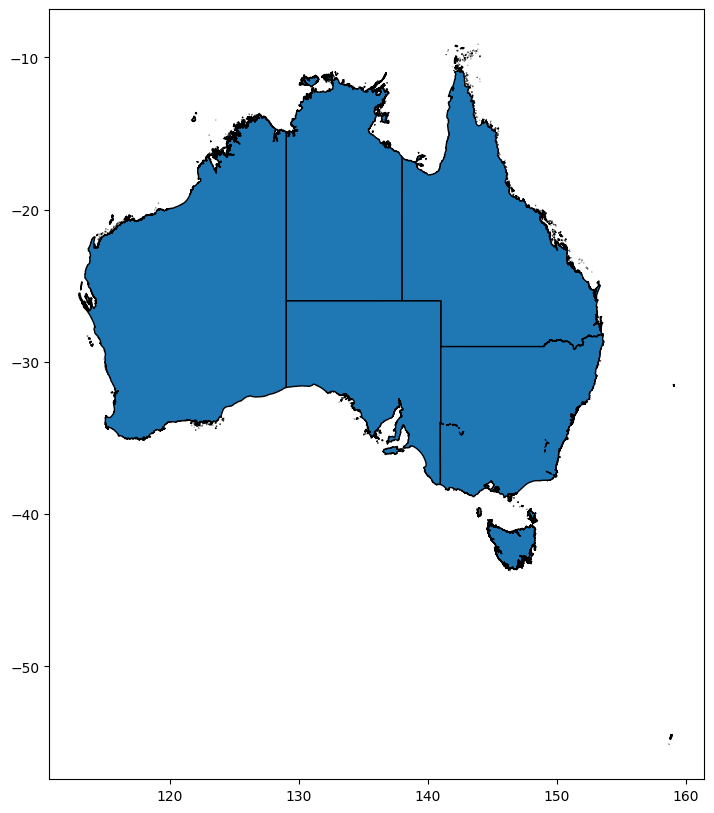

In [3]:
# Initial plotting
aus_gdf.plot(figsize=(10, 10), edgecolor='black')

In [4]:
# Finding the Neighbours for each region
neighbors = {}

for i, row in aus_gdf.iterrows():
    neighbors[i] = []

    for j, other in aus_gdf.iterrows():
        if i != j and row.geometry.intersects(other.geometry):
            neighbors[i].append(j)

print(neighbors)

{0: [1, 2, 3], 1: [0, 2, 4], 2: [0, 1, 3, 4], 3: [0, 2], 4: [1, 2]}


In [5]:
# Creating the secondary graph
import networkx as nx

G = nx.Graph()

# Adding nodes similar to the original map
for i in range(len(aus_gdf)):
    G.add_node(i)

# Add edges
for i, nbrs in neighbors.items():
    for j in nbrs:
        G.add_edge(i, j)

In [6]:
# Graph colouring - using greedy algorithm with DSATUR strategy
colors = nx.coloring.greedy_color(G, strategy="DSATUR")

# Map color indices back to the GeoDataFrame rows
aus_gdf["color_idx"] = aus_gdf.index.map(colors)

In [7]:
# Mapping with the Red, Blue, Green colour scheme
color_map = {
    0: "#C41616",  # red
    1: "#2196F3",  # blue
    2: "#5EFF00",  # green
}

aus_gdf["fill_color"] = aus_gdf["color_idx"].map(color_map)

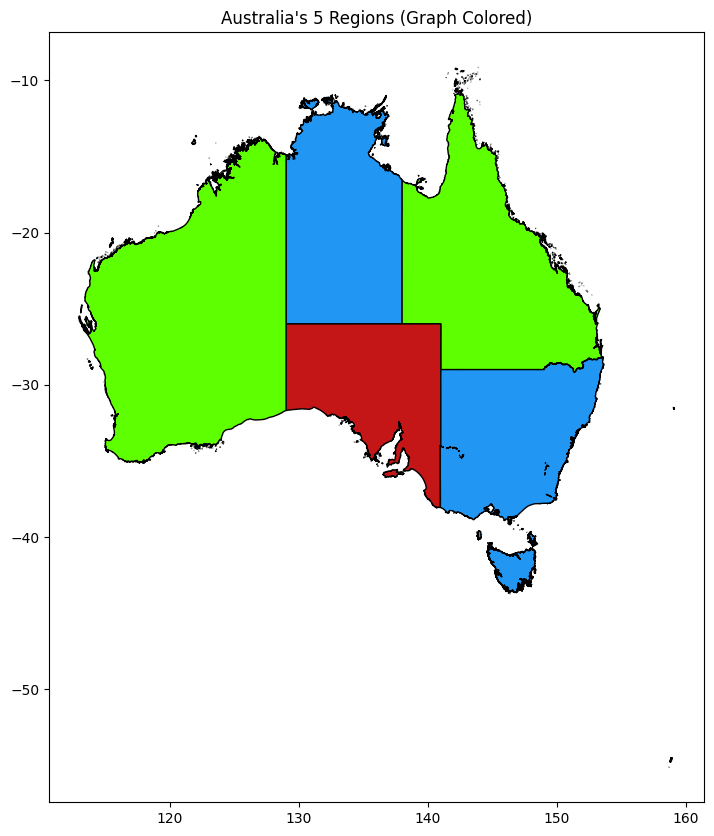

In [ ]:
# Final plotting
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

aus_gdf.plot(
    color=aus_gdf["fill_color"],
    edgecolor="black",
    ax=ax
)

plt.title("Australia's 5 Regions (Graph Colored)")
plt.show()